In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [14]:
#load dataset
df = pd.read_excel("C:/Users/Admin/Desktop/DATASET ONLINE RETAIL.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [15]:
#removing cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [16]:
#Removing missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [17]:
#removing duplicates
df = df.drop_duplicates()

In [18]:
#Convert date column to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [19]:
#Create Revenue Column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64


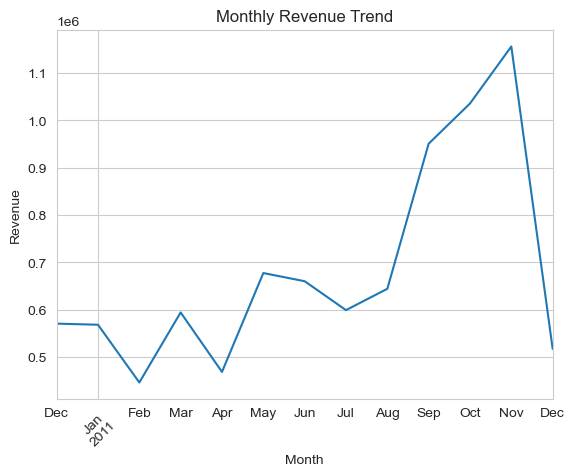

In [21]:
#Revenue Trend Over Time
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum()

print(monthly_revenue)

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

The output of this visualization is a line chart showing how revenue changes over time on a monthly basis. Each point on the line represents the total revenue generated in a particular month, while the line connecting these points helps illustrate the trend in sales performance over time.
The horizontal axis (X-axis) represents the months extracted from the InvoiceDate column. This shows the timeline of the business transactions.
The vertical axis (Y-axis) represents the total revenue generated during each month, which was calculated earlier using the formula:
Revenue = Quantity × UnitPrice
By plotting revenue across months, the chart provides a clear overview of how the business performed during different periods.

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


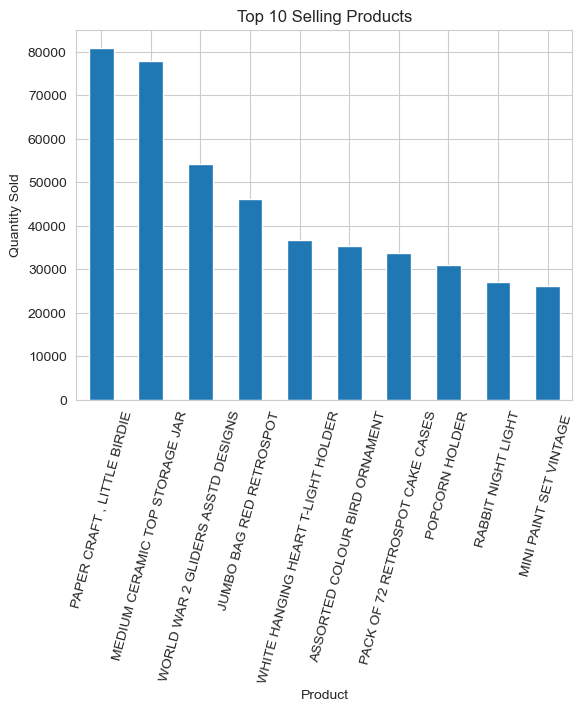

In [22]:
#Top-Selling Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print(top_products)
top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=75)
plt.show()

The output of this visualization is a bar chart displaying the top 10 products based on the total quantity sold.
Each bar in the chart represents a product, while the height of the bar shows the total number of units sold for that product across all transactions.
The X-axis represents the product descriptions, while the Y-axis represents the total quantity sold.
The products are sorted from the highest to the lowest quantity sold, which makes it easy to identify the most popular products.
From the chart, we can clearly see which products are purchased most frequently by customers.
Products with the tallest bars represent the highest-demand products, meaning they are sold more often compared to other items.
These products are important for the business because they:
Generate consistent sales
Reflect strong customer demand
Should be prioritized in inventory management

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


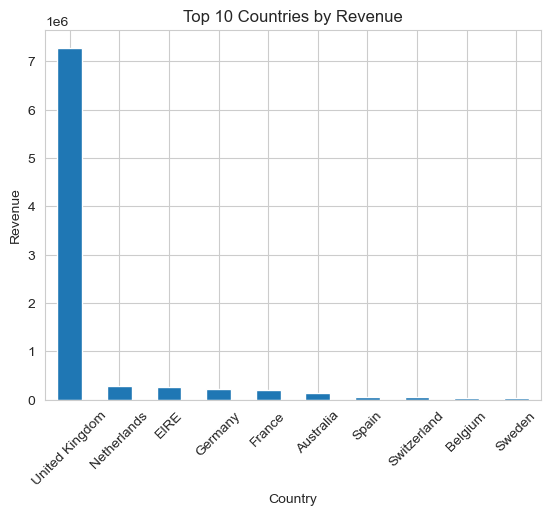

In [23]:
#High-Value Regions
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

print(top_countries)
top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Explanation:
The output of this visualization is a bar chart that displays the total sales revenue generated by different regions or countries. This chart helps compare how each region contributes to the overall business revenue.
In the bar chart, each bar represents a specific region (or country) from the dataset. The height of each bar indicates the total revenue generated from that region.
The X-axis (horizontal axis) represents the different regions or countries where sales occurred.
The Y-axis (vertical axis) represents the total revenue generated from those regions.
By using a bar chart, it becomes easier to visually compare the sales performance of each region.

From this visualization, we can clearly observe which regions generate the highest and lowest revenue.
Regions with taller bars indicate higher sales performance, meaning that customers in those regions purchase more products or generate higher revenue for the business.
Regions with shorter bars represent lower sales contributions, which may indicate:
Lower customer demand
Smaller market presence
Opportunities for business expansion

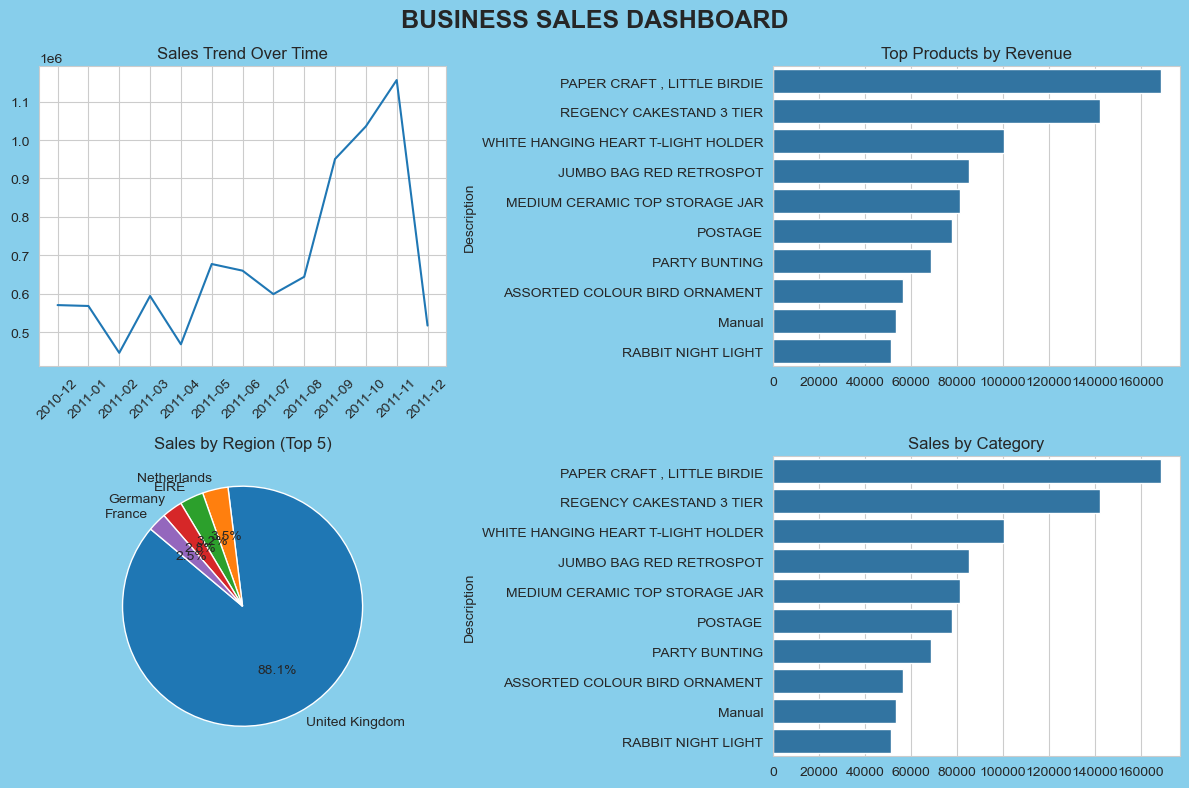

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load dataset
df = pd.read_excel("C:/Users/Admin/Desktop/DATASET ONLINE RETAIL.xlsx")

# -------------------------
# DATA CLEANING
# -------------------------

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove missing customer IDs
df = df.dropna(subset=['CustomerID'])

# Remove duplicates
df = df.drop_duplicates()

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']


# -------------------------
# ANALYSIS
# -------------------------

# Monthly revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Revenue'].sum()

# Top revenue products
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

# Sales by region
region_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)

# Sales by category (top products used as category example)
category_sales = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)


# -------------------------
# DASHBOARD
# -------------------------

fig, axes = plt.subplots(2,2, figsize=(12,8))

# Sky blue background
fig.patch.set_facecolor('skyblue')


# 1 Sales Trend
axes[0,0].plot(monthly_sales.index.astype(str), monthly_sales.values)
axes[0,0].set_title("Sales Trend Over Time")
axes[0,0].tick_params(axis='x', rotation=45)


# 2 Top Products by Revenue
sns.barplot(x=top_products.values, y=top_products.index, ax=axes[0,1])
axes[0,1].set_title("Top Products by Revenue")


# 3 Sales by Region
axes[1,0].pie(region_sales.values,
              labels=region_sales.index,
              autopct='%1.1f%%',
              startangle=140)

axes[1,0].set_title("Sales by Region (Top 5)")


# 4 Sales by Category
sns.barplot(x=category_sales.values, y=category_sales.index, ax=axes[1,1])
axes[1,1].set_title("Sales by Category")


# Dashboard title
plt.suptitle("BUSINESS SALES DASHBOARD", fontsize=18, fontweight='bold')

plt.tight_layout()

plt.show()